# Run YOLO detect.py (in remote repository) on coloab

## Prepareing

In [1]:
!nvidia-smi

Wed Jun 11 08:05:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17488, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 17488 (delta 0), reused 0 (delta 0), pack-reused 17486 (from 2)
Receiving objects: 100% (17488/17488), 16.59 MiB | 23.27 MiB/s, done.
Resolving deltas: 100% (11991/11991), done.


In [3]:
%ls

sample_data/  yolov5/


In [4]:
%cd yolov5

/content/yolov5


In [5]:
%ls

benchmarks.py    data/       LICENSE         README.zh-CN.md   tutorial.ipynb
CITATION.cff     detect.py   models/         requirements.txt  utils/
classify/        export.py   pyproject.toml  segment/          val.py
CONTRIBUTING.md  hubconf.py  README.md       train.py


In [6]:
%pip install -qr requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.8 MB/s eta 0:00:00


In [7]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No CUDA device available'}")

PyTorch version: 2.6.0+cu124
Tesla T4


In [8]:
%ls data/images

bus.jpg  zidane.jpg


## Run detect.py with variable argument

In [12]:
!python detect.py --weight yolov5m.pt --img 640 --conf 0.25 --source data/images/

detect: weights=['yolov5m.pt'], source=data/images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-420-g0c99ce80 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

100% 40.8M/40.8M [00:00<00:00, 212MB/s]

Fusing layers... 
YOLOv5m summary: 290 layers, 21172173 parameters, 0 gradients, 48.9 GFLOPs
image 1/2 /content/yolov5/data/images/bus.jpg: 640x480 4 persons, 1 bus, 50.1ms
image 2/2 /content/yolov5/data/images/zidane.jpg: 384x640 3 persons, 2 ties, 31.6ms
Speed: 0.5ms pre-process, 40.8ms inference, 76.4ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


## Show result image

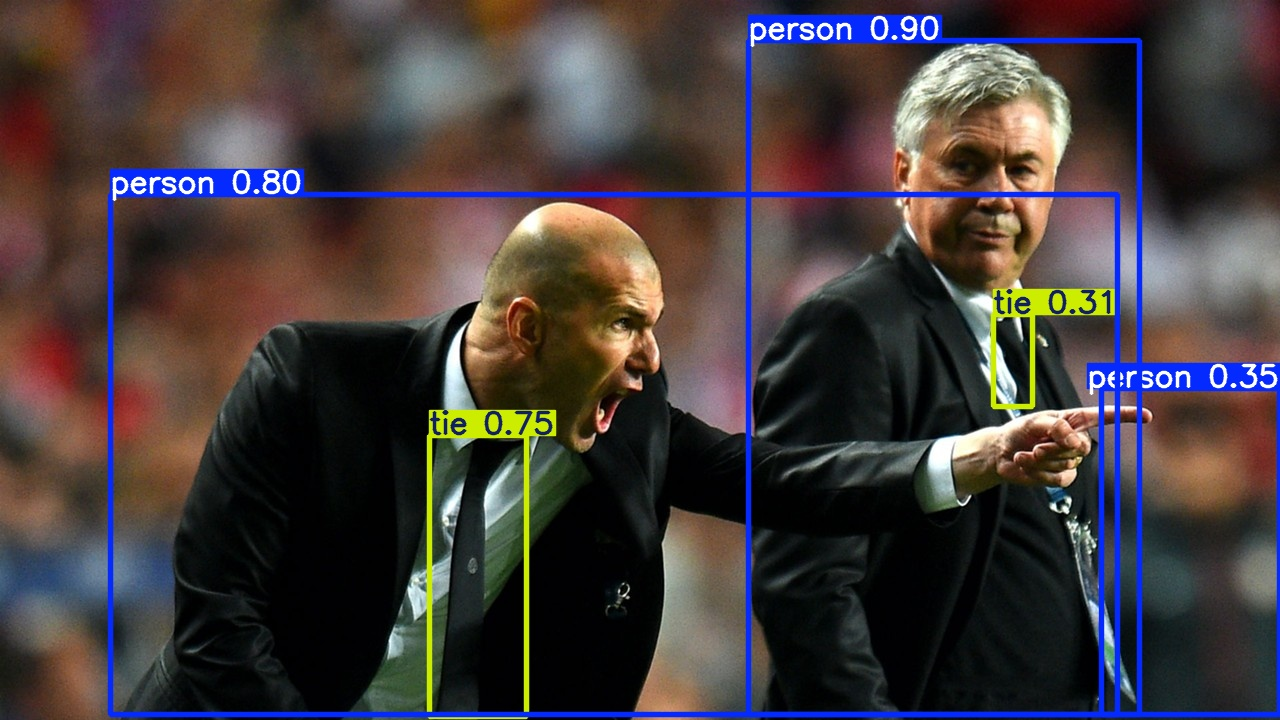

In [15]:
from IPython.display import Image

Image(filename='./runs/detect/exp2/zidane.jpg', width=400)

## Check the uploaded file

In [16]:
from google.colab import files
uploaded = files.upload()

Saving car_on_road.mp4 to car_on_road.mp4


In [18]:
%ls

benchmarks.py    data/       models/          requirements.txt  utils/
car_on_road.mp4  detect.py   __pycache__/     runs/             val.py
CITATION.cff     export.py   pyproject.toml   segment/          yolov5m.pt
classify/        hubconf.py  README.md        train.py          yolov5s.pt
CONTRIBUTING.md  LICENSE     README.zh-CN.md  tutorial.ipynb


## Object detection on uploaded file

In [19]:
!python detect.py --weights yolov5s.pt --img 640 --conf 0.4 --source car_on_road.mp4

detect: weights=['yolov5s.pt'], source=car_on_road.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-420-g0c99ce80 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
video 1/1 (1/223) /content/yolov5/car_on_road.mp4: 384x640 (no detections), 31.7ms
video 1/1 (2/223) /content/yolov5/car_on_road.mp4: 384x640 2 persons, 1 bicycle, 1 car, 1 bus, 1 truck, 8.0ms
video 1/1 (3/223) /content/yolov5/car_on_road.mp4: 384x640 2 persons, 1 bicycle, 2 cars, 1 bus, 8.0ms
video 1/1 (4/223) /content/yolov5/car_on_r